Relação estado reuso: 
{2: 4, 3: 3, 4: 2, 5: 1}


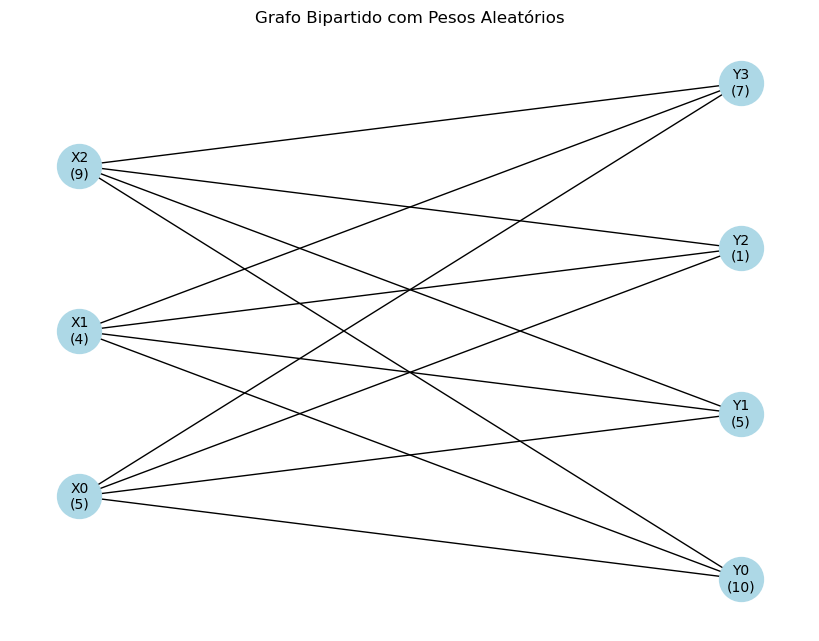

Iniciou às 2025-04-05 00:04:13.073
PQPPPPPPPPPP -  1
m = 3 | n = 4
PQPPPPPPPPPP -  2
m = 3 | n = 4
TAMANHO ESTADO:  2
ESTADO NO REUSO:  ('X2', 'Y3')
REUSO MAX:  4
PQPPPPPPPPPP -  1
m = 3 | n = 4
PQPPPPPPPPPP -  2
m = 3 | n = 4
TAMANHO ESTADO:  2
ESTADO NO REUSO:  ('X2', 'Y3')
REUSO MAX:  4
PQPPPPPPPPPP -  3
m = 3 | n = 4
TAMANHO ESTADO:  3
ESTADO NO REUSO:  ('X2', 'Y2', 'Y3')
REUSO MAX:  3
PQPPPPPPPPPP -  1
m = 3 | n = 4
PQPPPPPPPPPP -  2
m = 3 | n = 4
TAMANHO ESTADO:  2
ESTADO NO REUSO:  ('X2', 'Y2')
REUSO MAX:  4
PQPPPPPPPPPP -  1
m = 3 | n = 4
PQPPPPPPPPPP -  2
m = 3 | n = 4
TAMANHO ESTADO:  2
ESTADO NO REUSO:  ('X2', 'Y2')
REUSO MAX:  4
PQPPPPPPPPPP -  3
m = 3 | n = 4
TAMANHO ESTADO:  3
ESTADO NO REUSO:  ('X2', 'Y2', 'Y3')
REUSO MAX:  3
PQPPPPPPPPPP -  4
m = 3 | n = 4
TAMANHO ESTADO:  4
ESTADO NO REUSO:  ('X2', 'Y1', 'Y2', 'Y3')
REUSO MAX:  2
Estado ('X2', 'Y3') 
Estado ('X2', 'Y3') - reusos restantes: 3
PQPPPPPPPPPP -  3
m = 3 | n = 4
TAMANHO ESTADO:  3
ESTADO NO REUSO:  ('X2', 'Y

In [1]:
from geracao_grafos import *
from problemasPolinomiais.gulosoBicoloridoCiclo import *
from problemasPolinomiais.gulosoCompleto import *
from funcoesDP import *
from valG import *
from otimizacoesPD.caminho_otimizado_pd import *
import gc
import sys


def mainSemDp(grafo, pesos):
    
    inicio_tempo = time.time()
    melhor_valor, arvore_decisao, melhor_caminho = valor(grafo, pesos)
    fim_tempo = time.time()
    print("Sem Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)
    imprimirArvoreDecisao(arvore_decisao,False)


def mainDP(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp(grafo, pesos, memo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print(f"ESPAÇO OCUPADO PELA TABELA {sys.getsizeof(memo)} bytes" )
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    imprime_estados_nao_reutilizados(memo)
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)

def mainDP_Bipartido(grafo, pesos,m,n):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_bipartido(grafo, pesos, memo,m,n)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print(f"ESPAÇO OCUPADO PELA TABELA {sys.getsizeof(memo)} bytes" )
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    imprime_estados_nao_reutilizados(memo)
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)


def main():
    gc.collect()  # Força a coleta de lixo
    m, n = 3,4
    altura = 4
    gerar_reuso_estados(m, n)
    #grafo, pesos = gerar_grafo_ciclo(4)      # Gera um ciclo de 5 nós
    #grafo, pesos = gerar_grafo_completo(13)   # Gera um grafo completo de 6 nós
    #grafo, pesos = gerar_grafo_caminho(6)    # Gera um caminho de 4 nós
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido(m, n)
    grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido_completo(m, n)
    #grafo, pesos = grafoSimples()
    #grafo, pesos = arvoreCompleta(altura)
    

    #mainDP( grafo, pesos)
    mainDP_Bipartido(grafo,pesos,m,n)
    print("==================================================================================================")
    print("==================================================================================================")

    #main_caminho_otimiziado_pd(grafo,pesos)

    #mainSemDp( grafo, pesos)

    #mainBicoloracaoCaminho( grafo, pesos)
    #mainGulosoCompleto(grafo,pesos)
    #mainGulosoBicoloridoCiclo(grafo,pesos)

if __name__ == "__main__":
    main()